In [1]:
model_path = "/data_a100/models/"  # 本地的模型库路径，后续可以用于更多模型的测试
model_path = "../llms/Qwen2.5-14B-Instruct"  # 本地的模型库路径，后续可以用于更多模型的测试


In [2]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from captum.attr import FeatureAblation, LayerIntegratedGradients, IntegratedGradients

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0, 7"

In [4]:
# laska。用captum库来进行分析
import warnings

import bitsandbytes as bnb
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

from captum.attr import (
    FeatureAblation, 
    ShapleyValues,
    LayerIntegratedGradients, 
    LLMAttribution, 
    LLMGradientAttribution, 
    TextTokenInput, 
    TextTemplateInput,
    ProductBaselines,
)

# Ignore warnings due to transformers library
warnings.filterwarnings("ignore", ".*past_key_values.*")
warnings.filterwarnings("ignore", ".*Skipping this token.*")


In [5]:
def load_model(model_name, bnb_config):
    n_gpus = torch.cuda.device_count()
    max_memory = "20000MB"

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",  # dispatch efficiently the model on the available ressources
        max_memory = {i: max_memory for i in range(n_gpus)},
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name, token=True)

    # Needed for LLaMA tokenizer
    tokenizer.pad_token = tokenizer.eos_token

    return model, tokenizer

def create_bnb_config():
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    return bnb_config

In [6]:
bnb_config = create_bnb_config()
model, tokenizer = load_model(model_path, bnb_config)

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

In [11]:
eval_prompt = "Dave lives in Palm Coast, FL and is a lawyer. His personal interests include"

model_input = tokenizer(eval_prompt, return_tensors="pt").to("cuda")
model.eval()
with torch.no_grad():
    output_ids = model.generate(**model_input, max_new_tokens=30, temperature=0, do_sample=False)[0]
    response = tokenizer.decode(output_ids, skip_special_tokens=True)
    print(response)

Dave lives in Palm Coast, FL and is a lawyer. His personal interests include playing tennis and golf. He has been married for 20 years and has two children. He enjoys spending time with his family and friends. He


In [12]:
fa = FeatureAblation(model)

llm_attr = LLMAttribution(fa, tokenizer)

In [13]:
print(model_input)
print(model_input.input_ids.shape)

{'input_ids': tensor([[55730,  6305,   304, 32478, 15994,    11, 12772,   323,   374,   264,
         15417,    13,  5301,  4345, 11772,  2924]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}
torch.Size([1, 16])


In [14]:
for tid in model_input.input_ids[0]:
    print(tokenizer.decode(tid))
print(tokenizer.decode(model_input.input_ids[0]))

Dave
 lives
 in
 Palm
 Coast
,
 FL
 and
 is
 a
 lawyer
.
 His
 personal
 interests
 include
Dave lives in Palm Coast, FL and is a lawyer. His personal interests include


In [15]:
# laska 获取special token id 列表
print(tokenizer.special_tokens_map)
value_list= []
token_id_list = []
for key,values in tokenizer.special_tokens_map.items():
    print(values)
    if isinstance(values, list):
        value_list.extend(values)
        sub_token_id_list = []
        for value in values:
            token_id = tokenizer.encode(value)
            sub_token_id_list.append(token_id[0])
        print(len(sub_token_id_list), len(values))
        token_id_list.extend(sub_token_id_list)
    else:
        token_id = tokenizer.encode(values)
        token_id_list.append(token_id[0])
        value_list.append(values)
print(len(value_list), len(token_id_list))
print(token_id_list)
token_id_list = list(set(token_id_list))
print(len(token_id_list))



{'eos_token': '<|im_end|>', 'pad_token': '<|im_end|>', 'additional_special_tokens': ['<|im_start|>', '<|im_end|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>']}
<|im_end|>
<|im_end|>
['<|im_start|>', '<|im_end|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>']
13 13
15 15
[151645, 151645, 151644, 151645, 151646, 151647, 151648, 151649, 151650, 151651, 151652, 151653, 151654, 151655, 151656]
13


In [16]:
skip_tokens = token_id_list

inp = TextTokenInput(
    eval_prompt, 
    tokenizer,
    skip_tokens=skip_tokens,
)


In [ ]:

target = " include playing tennis and golf. He has been married for 20 years and has two children. He enjoys spending time with his family and friends. He"

attr_res = llm_attr.attribute(inp, target=target, skip_tokens=skip_tokens)


In [17]:
t_token = tokenizer.encode(target)
print(len(t_token))

28


In [18]:
print("attr to the output sequence:", attr_res.seq_attr.shape)  # shape(n_input_token)
print("attr to the output tokens:", attr_res.token_attr.shape)  # shape(n_output_token, n_input_token)

attr to the output sequence: torch.Size([16])
attr to the output tokens: torch.Size([28, 16])


In [19]:
def clean_token(t, tokenizer):
    # 去掉 SentencePiece 的下划线前缀
  
    t = t.replace("▁", " ")
    # 把 GPT/BPE 的 Ġ 前缀改成你想要的
    t = t.replace("Ġ", "_")   # 如果想要前面是空格，就用 " " 代替 "_"
    
    # 显式化空白
    if t == " ":
        t = "[SP]"
    t = t.replace("\n", "[NL]").replace("\t", "[TAB]")
    # 对特殊 token 做统一替换（按你需要增删）
    if t in ["<|im_start|>", "<|im_end|>"]:
        t = "[SPECIAL]"
    return t

input_tokens_clean  = [clean_token(t, tokenizer) for t in attr_res.input_tokens]
output_tokens_clean = [clean_token(t, tokenizer) for t in attr_res.output_tokens]

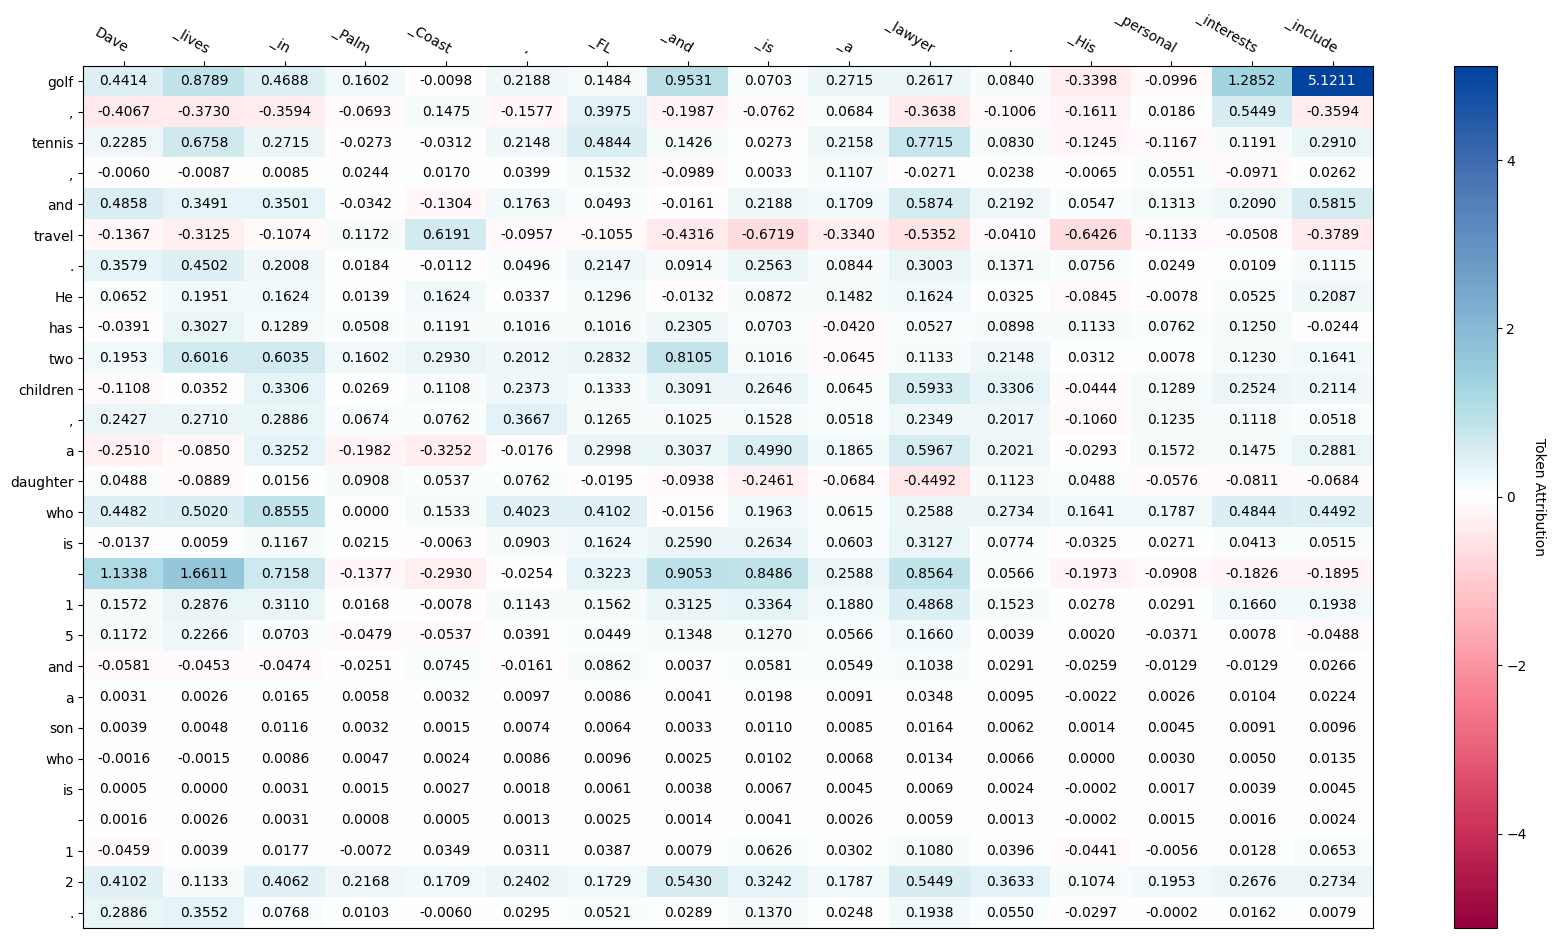

In [20]:
input_tokens_clean  = [clean_token(t, tokenizer) for t in attr_res.input_tokens]
attr_res.input_tokens = input_tokens_clean
attr_res.plot_token_attr(show=True)


In [53]:
print(attr_res.seq_attr)






tensor([16.5156, 12.6719,  4.1719, -0.2969,  0.5625,  0.9531,  1.1875,  6.4531,
         4.4531,  0.9688, 10.3281,  2.3281, -0.7031,  1.7031,  3.7656,  8.4531],
       device='cuda:0')


In [21]:
# 打印所有子层的名称
for name, module in model.named_modules():
    print(name)


model
model.embed_tokens
model.layers
model.layers.0
model.layers.0.self_attn
model.layers.0.self_attn.q_proj
model.layers.0.self_attn.k_proj
model.layers.0.self_attn.v_proj
model.layers.0.self_attn.o_proj
model.layers.0.mlp
model.layers.0.mlp.gate_proj
model.layers.0.mlp.up_proj
model.layers.0.mlp.down_proj
model.layers.0.mlp.act_fn
model.layers.0.input_layernorm
model.layers.0.post_attention_layernorm
model.layers.1
model.layers.1.self_attn
model.layers.1.self_attn.q_proj
model.layers.1.self_attn.k_proj
model.layers.1.self_attn.v_proj
model.layers.1.self_attn.o_proj
model.layers.1.mlp
model.layers.1.mlp.gate_proj
model.layers.1.mlp.up_proj
model.layers.1.mlp.down_proj
model.layers.1.mlp.act_fn
model.layers.1.input_layernorm
model.layers.1.post_attention_layernorm
model.layers.2
model.layers.2.self_attn
model.layers.2.self_attn.q_proj
model.layers.2.self_attn.k_proj
model.layers.2.self_attn.v_proj
model.layers.2.self_attn.o_proj
model.layers.2.mlp
model.layers.2.mlp.gate_proj
model.l

In [8]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path, 
    device_map="auto", 
    torch_dtype=torch.bfloat16, 
    trust_remote_code=True,
    attn_implementation="eager"  # 关键修复行
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

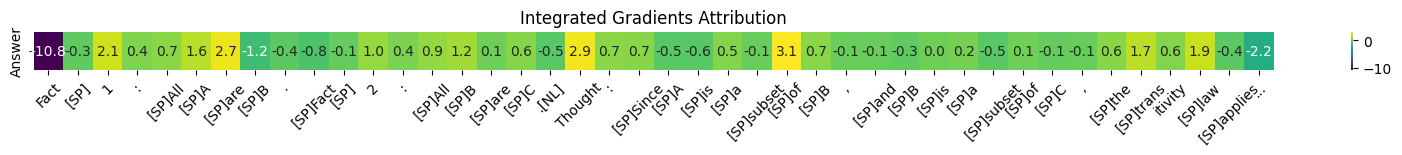

In [9]:
# ---------------------------
# 2 构造输入
# ---------------------------
context = "Tom has 3 apples."
cot = "He buys 2 more apples."
answer = "5"

context = "Fact 1: All A are B. Fact 2: All B are C."
cot = "Thought: Since A is a subset of B, and B is a subset of C, the transitivity law applies..."
answer = "The conclusion is that A is also C."

prompt_text = context + "\n" + cot

device = model.device
prompt_ids = tokenizer.encode(prompt_text, return_tensors="pt").to(device)
answer_ids = tokenizer.encode(answer, return_tensors="pt", add_special_tokens=False).to(device)

input_ids = torch.cat([prompt_ids, answer_ids], dim=-1)

prompt_len = prompt_ids.shape[1]
answer_len = answer_ids.shape[1]


# ---------------------------
# 3 获取embedding
# ---------------------------
embedding_layer = model.get_input_embeddings()
input_embeds = embedding_layer(input_ids)

baseline = torch.zeros_like(input_embeds)


# ---------------------------
# 4 forward函数
# ---------------------------
def forward_func(inputs_embeds):

    outputs = model(inputs_embeds=inputs_embeds)
    logits = outputs.logits

    target_pos = prompt_len - 1
    target_token = answer_ids[0, 0]

    return logits[:, target_pos, target_token]


# ---------------------------
# 5 Integrated Gradients
# ---------------------------
ig = IntegratedGradients(forward_func)

attributions, delta = ig.attribute(
    inputs=input_embeds,
    baselines=baseline,
    n_steps=50,
    return_convergence_delta=True
)

# token attribution
attr = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()

# 只保留prompt部分
attr_prompt = attr[:prompt_len]


# ---------------------------
# 6 token标签
# ---------------------------
prompt_tokens = [
    tokenizer.decode([tid]).replace(" ", "[SP]").replace("\n", "[NL]")
    for tid in prompt_ids[0]
]

# ---------------------------
# 7 heatmap
# ---------------------------
matrix = attr_prompt.reshape(1, -1)

plt.figure(figsize=(20, 0.5))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".1f",
    annot_kws={"size":10},
    xticklabels=prompt_tokens,
    yticklabels=["Answer"],
    cmap="viridis"
)

plt.title("Integrated Gradients Attribution")
plt.xticks(rotation=45)
plt.show()

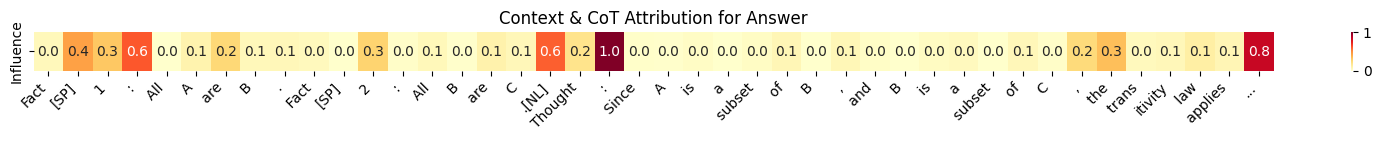

In [4]:
def get_attribution_scores(context_text, cot_text, answer_text):
    """
    计算 Context 和 CoT 对 Answer 的归因得分
    """
    # 构造完整输入
    full_prompt = f"{context_text}\n{cot_text}"
    input_ids = tokenizer.encode(full_prompt, return_tensors="pt").to(model.device)
    # 【核心修改点】
    readable_tokens = []
    for tid in input_ids[0]:
        # 将 Token ID 逐个转回人类可读的字符串
        token_str = tokenizer.decode([tid])
        
        # 进一步美化：将换行符和空格显式化，方便在图中查看
        token_str = token_str.replace("\n", "[NL]").replace("\t", "[TAB]")
        if token_str == " ":
            token_str = "[SP]" # 或者保持原样，取决于你是否想看空格的贡献
        readable_tokens.append(token_str)
    answer_ids = tokenizer.encode(answer_text, add_special_tokens=False)
    
    # 获取 Embedding 层 (Qwen2 的 embedding 层通常叫 model.embed_tokens)
    embeddings = model.get_input_embeddings()
    
    # 提取输入的 embedding 并开启梯度追踪
    input_embeds = embeddings(input_ids).detach().requires_grad_(True)
    
    # 前向传播：计算 Answer 第一个 token 的概率 (也可对整个答案序列求和)
    # 这里以答案的第一个关键 Token 为目标
    outputs = model(inputs_embeds=input_embeds)
    logits = outputs.logits
    
    # 假设我们关注答案序列在最后一个位置产生的概率
    target_token_idx = answer_ids[0] 
    target_logit = logits[0, -1, target_token_idx]
    
    # 反向传播获取梯度
    model.zero_grad()
    target_logit.backward()
    
    # 计算 Input X Gradient
    # [1, seq_len, hidden_dim] -> [seq_len]
    grads = input_embeds.grad
    # 2. 这里的 attribution 仍然是 BFloat16
    attribution = (grads * input_embeds).sum(dim=-1).squeeze(0).abs()
    # attribution = attribution.cpu().detach().numpy()
    # 3. 【核心修复】先转为 float32，再转为 numpy
    attribution = attribution.to(torch.float32).cpu().detach().numpy()
    
    # 4. 归一化得分 (防止除以 0)
    denom = attribution.max() - attribution.min()
    if denom == 0:
        attribution = np.zeros_like(attribution)
    else:
        attribution = (attribution - attribution.min()) / denom
    
    # 归一化得分
    # attribution = (attribution - attribution.min()) / (attribution.max() - attribution.min())
    
    # 将得分与 Token 对应
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    # return tokens, attribution
    return readable_tokens, attribution

# 3. 可视化函数
def plot_heatmap(tokens, scores, title="Feature Attribution"):
    plt.figure(figsize=(20, 0.5))
    sns.heatmap([scores], annot=True,  fmt=".1f",xticklabels=tokens, yticklabels=["Influence"], cmap="YlOrRd",annot_kws={"size":10})
   
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.show()

# --- 使用示例 ---
context = "Fact 1: All A are B. Fact 2: All B are C."
cot = "Thought: Since A is a subset of B, and B is a subset of C, the transitivity law applies..."
answer = "The conclusion is that A is also C."

tokens, scores = get_attribution_scores(context, cot, answer)
plot_heatmap(tokens, scores, title="Context & CoT Attribution for Answer")

['Fact', '[SP]', '1', ':', '[SP]All', '[SP]humans', '[SP]are', '[SP]mortal', '.[NL]', 'Thought', ':', '[SP]S', 'ocrates', '[SP]is', '[SP]human', '.']
['So', '[SP]S', 'ocrates', '[SP]is', '[SP]mortal', '.']
input_emdeds: torch.Size([1, 22, 5120])
torch.Size([1, 22, 152064])
input_embeds <class 'torch.Tensor'> torch.Size([1, 22, 5120]) tensor(2.1875, device='cuda:0', dtype=torch.bfloat16,
       grad_fn=<SelectBackward0>) tensor([[[-0.0288,  0.0014,  0.0044,  ..., -0.0220,  0.0048,  0.0245],
         [-0.0056,  0.0034,  0.0003,  ...,  0.0026, -0.0012, -0.0030],
         [-0.0045,  0.0035,  0.0048,  ...,  0.0013,  0.0020,  0.0021],
         ...,
         [-0.0142,  0.0007,  0.0015,  ..., -0.0043, -0.0013,  0.0101],
         [-0.0211, -0.0204, -0.0125,  ...,  0.0037, -0.0011,  0.0023],
         [ 0.0041, -0.0022,  0.0014,  ..., -0.0016, -0.0048,  0.0027]]],
       device='cuda:0', dtype=torch.bfloat16, requires_grad=True)
tensor([[[-0.0288,  0.0014,  0.0044,  ..., -0.0220,  0.0048,  0.0245

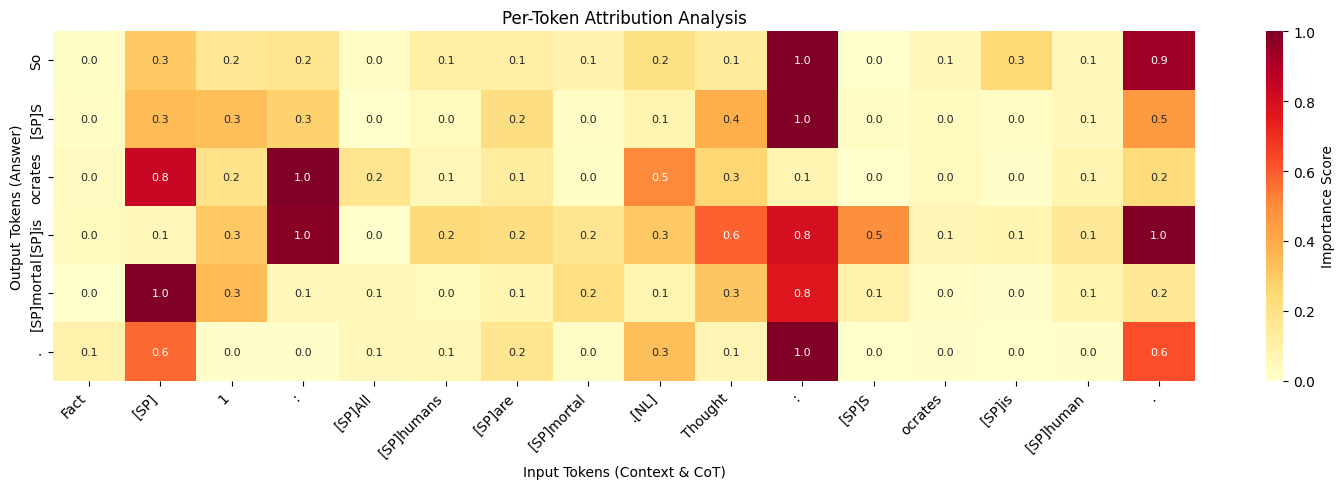

In [ ]:
from copy import deepcopy
def get_attribution_matrix(context_text, cot_text, answer_text):
    """
    计算 Answer 中每个 token 对 Context+CoT 的逐词归因得分 (2D 矩阵)
    """
    # 1. 编码
    prompt_text = f"{context_text}\n{cot_text}"
    prompt_ids = tokenizer.encode(prompt_text, return_tensors="pt").to(model.device)
    answer_ids = tokenizer.encode(answer_text, return_tensors="pt", add_special_tokens=False).to(model.device)
    full_input_ids = torch.cat([prompt_ids, answer_ids], dim=-1)
    # print("prompt:")
    # print(prompt_ids.shape)
    # print("answer:")
    # print(answer_ids.shape, answer_ids)
    # print(full_input_ids.shape)
    # 准备可读 Token 标签
    prompt_tokens = [tokenizer.decode([tid]).replace("\n", "[NL]").replace(" ", "[SP]") for tid in prompt_ids[0]]
    answer_tokens = [tokenizer.decode([tid]).replace("\n", "[NL]").replace(" ", "[SP]") for tid in answer_ids[0]]
    print(prompt_tokens)
    print(answer_tokens)
    # 2. 获取 Embedding 并开启梯度
    embeddings = model.get_input_embeddings()
    # 必须每次 detach 并设置 requires_grad
    input_embeds = embeddings(full_input_ids).detach().requires_grad_(True)
    print("input_emdeds:", input_embeds.shape)
    # 3. 前向传播
    outputs = model(inputs_embeds=input_embeds)
    logits = outputs.logits
    print(logits.shape)
    prompt_len = prompt_ids.shape[1]
    answer_len = answer_ids.shape[1]
    
    # 用于存储 2D 归因矩阵: [Answer_Len, Prompt_Len]
    attribution_matrix = []
    middle_res = []
    # 4. 逐个 Answer Token 进行归因计算
    for i in range(answer_len):
        # 当前预测的是 Answer 的第 i 个词，对应的 Logit 在 prompt_len - 1 + i 的位置
        current_pos = prompt_len - 1 + i
        target_token_id = answer_ids[0, i]
        # print("current {i} is:", target_token_id)
        # 提取当前 Token 的标量得分
        target_logit = logits[0, current_pos, target_token_id]
        # print(target_logit,"target logit ")
        # 清除之前的梯度
        if input_embeds.grad is not None:
            input_embeds.grad.zero_()
        middle_res.append(deepcopy(input_embeds))
        print("input_embeds",type(input_embeds), input_embeds.shape, target_logit, input_embeds)
        # 反向传播 (retain_graph=True 允许我们为多个 token 反复求导)
        target_logit.backward(retain_graph=True)
        print(input_embeds)
        # 计算当前 Answer Token 的 Input X Gradient 归因
        grads = input_embeds.grad
        # 计算整个 Input 序列的得分 [Full_Seq_Len]
        current_attr = (grads * input_embeds).sum(dim=-1).squeeze(0).abs()
        
        # 只截取 Prompt 部分的贡献
        input_part_attr = current_attr[:prompt_len].to(torch.float32).cpu().detach().numpy()
        attribution_matrix.append(input_part_attr)

    attribution_matrix = np.array(attribution_matrix)

    # 5. 矩阵归一化 (让每一行即每个 Answer Token 的贡献都在 0-1 之间，方便对比)
    row_min = attribution_matrix.min(axis=1, keepdims=True)
    row_max = attribution_matrix.max(axis=1, keepdims=True)
    denom = row_max - row_min
    # 防止除以 0
    denom[denom == 0] = 1.0
    normalized_matrix = (attribution_matrix - row_min) / denom
    
    return prompt_tokens, answer_tokens, normalized_matrix

def plot_2d_attribution(x_tokens, y_tokens, matrix, title="Token-to-Token Attribution"):
    # 根据序列长度自动调整画布大小
    width = max(15, len(x_tokens) * 0.4)
    height = max(5, len(y_tokens) * 0.6)
    
    plt.figure(figsize=(width, height))
    
    sns.heatmap(
        matrix, 
        annot=True, 
        fmt=".1f", 
        xticklabels=x_tokens, 
        yticklabels=y_tokens, 
        cmap="YlOrRd",
        cbar_kws={'label': 'Importance Score'},
        annot_kws={"size": 8}
    )
    
    plt.xlabel("Input Tokens (Context & CoT)")
    plt.ylabel("Output Tokens (Answer)")
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# --- 执行示例 ---
context = "Fact 1: All humans are mortal."
cot = "Thought: Socrates is human."
answer = "So Socrates is mortal."

x_labels, y_labels, attr_matrix = get_attribution_matrix(context, cot, answer)
plot_2d_attribution(x_labels, y_labels, attr_matrix, title="Per-Token Attribution Analysis")

In [5]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def compute_cot_attribution(model, tokenizer, context_text, cot_text, answer_text):
    """
    Compute attribution of Context + CoT to the Answer generation.
    Uses teacher-forcing over the whole answer sequence.
    """

    device = model.device

    # -------- 1 构造输入 --------
    prompt = f"{context_text}\n{cot_text}"

    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)
    answer_ids = tokenizer.encode(answer_text, add_special_tokens=False)

    # teacher forcing 输入
    input_ids = prompt_ids + answer_ids[:-1]

    input_ids = torch.tensor(input_ids).unsqueeze(0).to(device)

    # -------- 2 获取 embedding --------
    embeddings = model.get_input_embeddings()
    input_embeds = embeddings(input_ids).detach().requires_grad_(True)

    # -------- 3 前向传播 --------
    outputs = model(inputs_embeds=input_embeds)
    logits = outputs.logits

    # -------- 4 计算 Answer token 的 log prob --------
    loss = 0

    for i, target_token in enumerate(answer_ids):
        pos = len(prompt_ids) + i - 1

        if pos < 0:
            continue

        logit = logits[0, pos, target_token]
        print("this is logit:", logit.item())
        print("this is target token:", tokenizer.decode([target_token]))
        loss += logit

    # -------- 5 反向传播 --------
    model.zero_grad()
    loss.backward()

    grads = input_embeds.grad

    # -------- 6 Input x Gradient attribution --------
    attribution = (grads * input_embeds).sum(dim=-1).squeeze(0).abs()

    attribution = attribution.to(torch.float32).cpu().detach().numpy()

    # -------- 7 归一化 --------
    denom = attribution.max() - attribution.min()

    if denom == 0:
        attribution = np.zeros_like(attribution)
    else:
        attribution = (attribution - attribution.min()) / denom

    # -------- 8 token 可读化 --------
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])  # 这个函数会产生乱码****why？
    tokens = [tokenizer.decode([tid]) for tid in input_ids[0]]
    print("原始 tokens:", tokens)
    readable_tokens = []

    for tok in tokens:

        tok = tok.replace("\n", "[NL]")
        tok = tok.replace("\t", "[TAB]")

        if tok == " ":
            tok = "[SP]"

        readable_tokens.append(tok)

    # -------- 9 计算 Context / CoT attribution --------
    context_len = len(tokenizer.encode(context_text, add_special_tokens=False))
    cot_len = len(tokenizer.encode(cot_text, add_special_tokens=False))

    context_attr = attribution[:context_len].sum()
    cot_attr = attribution[context_len:context_len + cot_len].sum()

    return {
        "tokens": readable_tokens,
        "scores": attribution,
        "context_score": float(context_attr),
        "cot_score": float(cot_attr),
        "cot_ratio": float(cot_attr / (context_attr + cot_attr + 1e-8))
    }


# -------------------------------
# 可视化
# -------------------------------

def plot_attribution(tokens, scores, title="Attribution Heatmap"):

    plt.figure(figsize=(max(12, len(tokens) * 0.4), 1.5))

    sns.heatmap(
        [scores],
        xticklabels=tokens,
        yticklabels=["Influence"],
        cmap="YlOrRd",
        cbar=True
    )

    plt.title(title)
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

this is logit: 0.97265625
this is target token: The
this is logit: 23.0
this is target token:  conclusion
this is logit: 22.625
this is target token:  is
this is logit: 24.25
this is target token:  that
this is logit: 24.625
this is target token:  A
this is logit: 26.875
this is target token:  is
this is logit: 25.5
this is target token:  also
this is logit: 23.75
this is target token:  C
this is logit: 23.5
this is target token: .
原始 tokens: ['Fact', ' ', '1', ':', ' All', ' A', ' are', ' B', '.', ' Fact', ' ', '2', ':', ' All', ' B', ' are', ' C', '.\n', 'Thought', ':', ' Since', ' A', ' is', ' a', ' subset', ' of', ' B', ',', ' and', ' B', ' is', ' a', ' subset', ' of', ' C', ',', ' the', ' trans', 'itivity', ' law', ' applies', '.', 'The', ' conclusion', ' is', ' that', ' A', ' is', ' also', ' C']


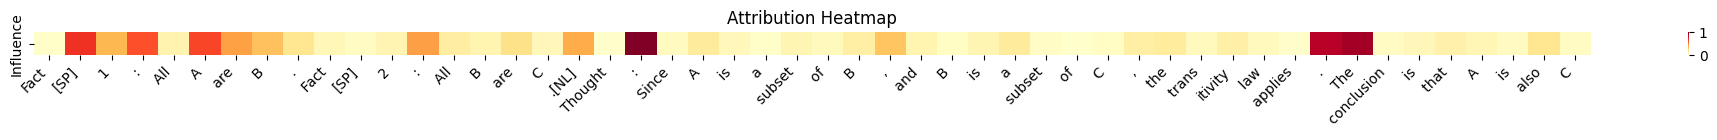

Context attribution: 4.792662620544434
CoT attribution: 3.4777512550354004
CoT ratio: 0.4205050802338569


In [6]:
context = "Fact 1: All A are B. Fact 2: All B are C."
cot = "Thought: Since A is a subset of B, and B is a subset of C, the transitivity law applies."
answer = "The conclusion is that A is also C."

result = compute_cot_attribution(
    model,
    tokenizer,
    context,
    cot,
    answer
)

plot_attribution(result["tokens"], result["scores"])

print("Context attribution:", result["context_score"])
print("CoT attribution:", result["cot_score"])
print("CoT ratio:", result["cot_ratio"])

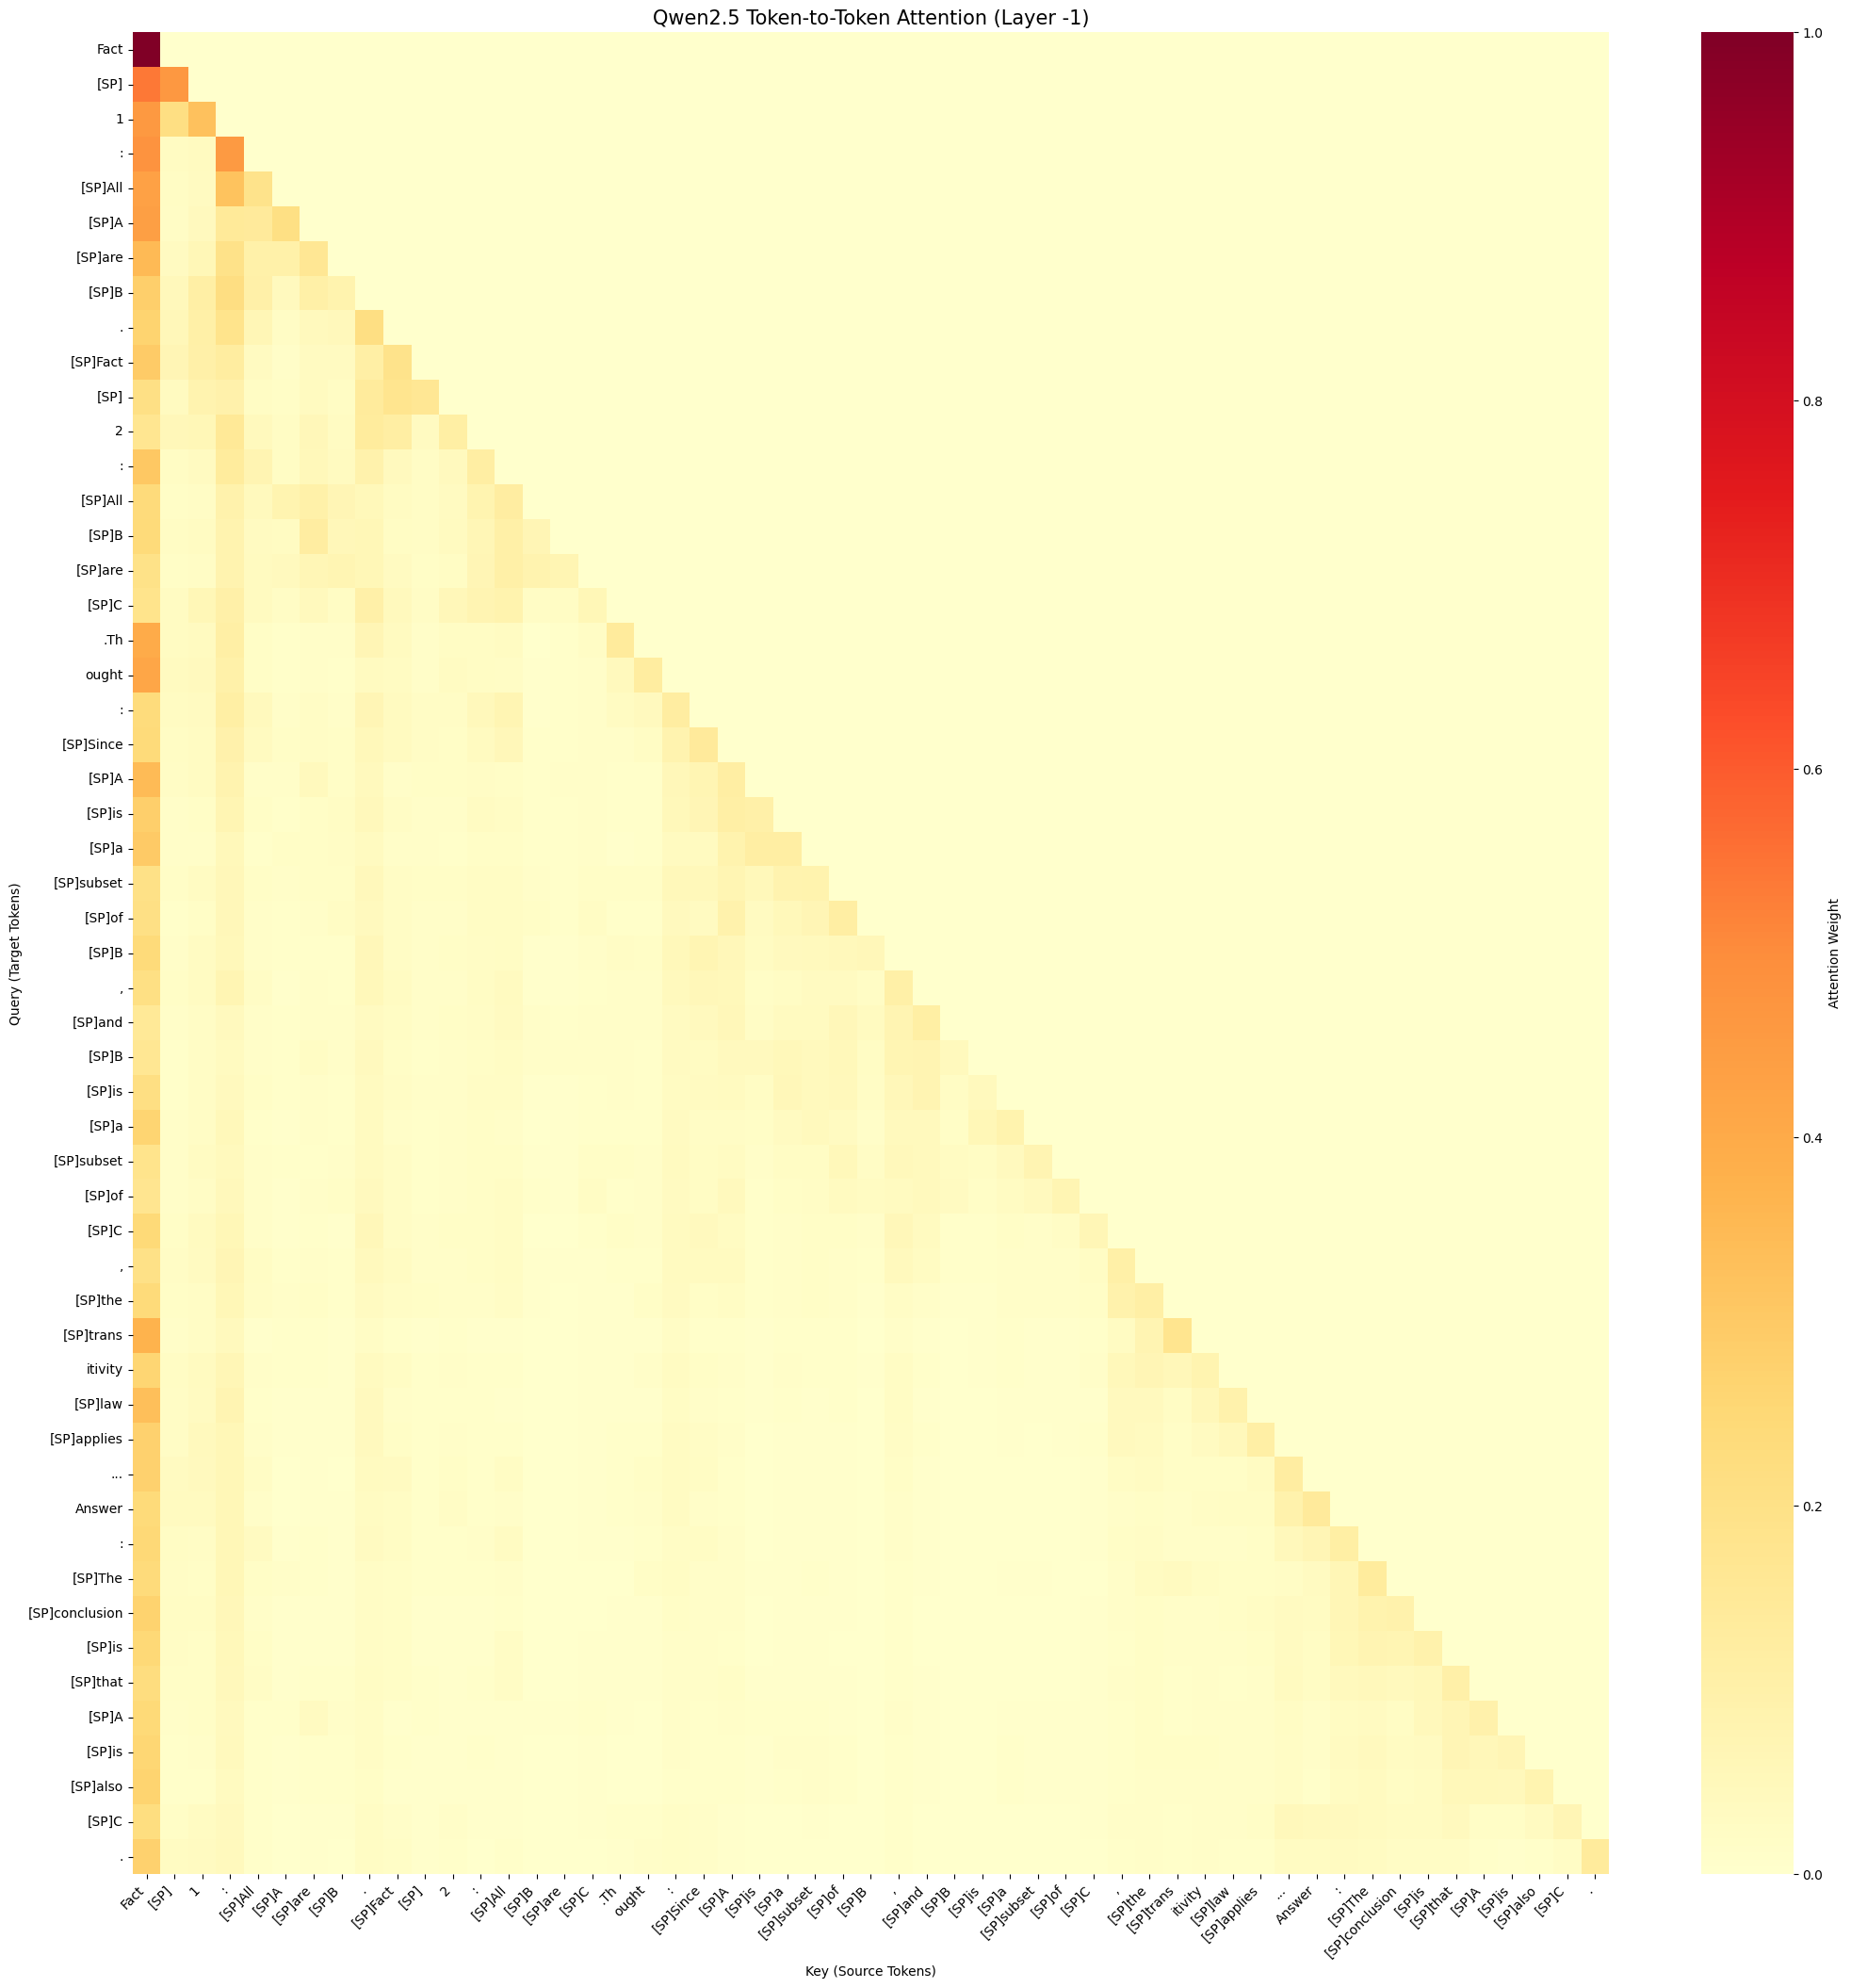

In [7]:
def plot_full_attention_heatmap(context_and_answer_text, layer_idx=-1):
    """
    提取并可视化全量 Token 之间的注意力矩阵
    layer_idx: 默认查看最后一层 (-1)，这是语义和逻辑信息最集中的地方
    """
    # 1. 编码并获取注意力权重
    inputs = tokenizer(context_and_answer_text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    
    # 获取特定层的注意力: shape [batch, heads, seq_len, seq_len]
    # Qwen2.5 的注意力权重在 outputs.attentions 中
    attentions = outputs.attentions[layer_idx]
    
    # 2. 对所有 Head 取平均 (或取 Max)
    # [1, heads, seq_len, seq_len] -> [seq_len, seq_len]
    avg_attention = attentions.mean(dim=1).squeeze(0)
    
    # 3. 【核心修复】处理 BFloat16 并转为 Numpy
    avg_attention = avg_attention.to(torch.float32).cpu().numpy()
    
    # 4. 【核心修复】清洗 Token 标签
    raw_tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    readable_tokens = []
    for t in raw_tokens:
        # 使用 decode 还原字节级编码 (解决 Ġ 和 Ċ 问题)
        decoded = tokenizer.convert_tokens_to_string([t])
        decoded = decoded.replace("\n", "[NL]").replace(" ", "[SP]")
        readable_tokens.append(decoded)

    # 5. 绘图
    plt.figure(figsize=(max(len(readable_tokens)*0.4, 10), max(len(readable_tokens)*0.4, 8)))
    
    # 使用 log 缩放可以更容易观察到微弱的注意力联系
    sns.heatmap(
        avg_attention, 
        xticklabels=readable_tokens, 
        yticklabels=readable_tokens, 
        cmap="YlOrRd", 
        cbar_kws={'label': 'Attention Weight'}
    )
    
    plt.title(f"Qwen2.5 Token-to-Token Attention (Layer {layer_idx})", fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Key (Source Tokens)")
    plt.ylabel("Query (Target Tokens)")
    plt.tight_layout()
    plt.show()

# --- 使用示例 ---
full_text = "Fact 1: All A are B. Fact 2: All B are C.Thought: Since A is a subset of B, and B is a subset of C, the transitivity law applies...Answer: The conclusion is that A is also C."
plot_full_attention_heatmap(full_text)

In [8]:
import re

def get_granularity_map(tokens, granularity="word"):
    """
    根据粒度将 tokens 分组。
    返回: 
        groups: 字符串列表 (聚合后的文本)
        group_indices: 列表, 记录每个 token 属于哪个 group
    """
    groups = []
    group_indices = []
    current_group = ""
    group_idx = -1

    for i, t in enumerate(tokens):
        # 清洗 token
        clean_t = tokenizer.decode(tokenizer.encode(t, add_special_tokens=False))
        
        # 判定是否开启新组
        is_new = False
        if granularity == "token":
            is_new = True
        elif granularity == "word":
            # 单词开头通常带有空格标识 (Qwen 中为 ' ')
            if t.startswith(' ') or i == 0:
                is_new = True
        elif granularity == "sentence":
            # 简单正则判定：前一个 token 包含句末标点
            if i == 0 or re.search(r'[.。!！?？\n]', tokens[i-1]):
                is_new = True
        
        if is_new:
            if current_group: groups.append(current_group)
            current_group = clean_t
            group_idx += 1
        else:
            current_group += clean_t
        
        group_indices.append(group_idx)
    
    groups.append(current_group)
    return groups, group_indices

def aggregate_scores(scores, group_indices, method="mean"):
    """
    将 Token 级的得分聚合到 Group 级
    聚合公式示例 (Mean): $$S_{group} = \frac{1}{|G|} \sum_{i \in G} s_i$$
    """
    num_groups = max(group_indices) + 1
    new_scores = np.zeros(num_groups)
    counts = np.zeros(num_groups)
    
    for i, g_idx in enumerate(group_indices):
        new_scores[g_idx] += scores[i]
        counts[g_idx] += 1
        
    if method == "mean":
        new_scores = new_scores / np.maximum(counts, 1)
    return new_scores

<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1242699/2186111188.py:45: SyntaxWarning: invalid escape sequence '\s'
  """


In [9]:
def get_multi_granularity_attribution(context_text, cot_text, answer_text, granularity="sentence"):
    # 1. 正常计算 Token 级的 Attribution (复用之前的逻辑)
    # ... [此处省略之前的梯度计算代码，得到 tokens 和 scores] ...
    
    # 2. 获取映射关系
    groups, group_indices = get_granularity_map(tokens, granularity=granularity)
    
    # 3. 聚合得分
    agg_scores = aggregate_scores(scores, group_indices, method="mean")
    
    return groups, agg_scores

In [10]:
def plot_multi_granularity_attention(full_text, granularity="word", layer_idx=-1):
    # 1. 获取 Token 级注意力矩阵 [seq, seq]
    # ... [复用之前 eager 模式下的注意力提取代码，得到 avg_attention 和 raw_tokens] ...
    
    # 2. 分别计算行和列的聚合映射
    labels, indices = get_granularity_map(raw_tokens, granularity=granularity)
    num_groups = len(labels)
    
    # 3. 二维聚合：将 [seq, seq] 缩减为 [group, group]
    agg_matrix = np.zeros((num_groups, num_groups))
    counts = np.zeros((num_groups, num_groups))
    
    for i in range(len(raw_tokens)):
        for j in range(len(raw_tokens)):
            g_i = indices[i]
            g_j = indices[j]
            agg_matrix[g_i, g_j] += avg_attention[i, j]
            counts[g_i, g_j] += 1
            
    agg_matrix = agg_matrix / np.maximum(counts, 1)
    
    # 4. 绘图 (labels 作为坐标轴)
    plt.figure(figsize=(12, 10))
    sns.heatmap(agg_matrix, xticklabels=labels, yticklabels=labels, cmap="YlOrRd")
    plt.title(f"Granularity: {granularity} (Layer {layer_idx})")
    plt.show()

In [ ]:
def attribution_matrix(model, tokenizer, input_text, output_text):

    prompt_ids = tokenizer.encode(input_text, return_tensors="pt").to(model.device)
    output_ids = tokenizer.encode(output_text, add_special_tokens=False)
    print(prompt_ids.shape)
    print(len(output_ids))
    embeddings = model.get_input_embeddings()

    matrix = []

    for t, token in enumerate(output_ids):

        input_embeds = embeddings(prompt_ids).detach().requires_grad_(True)

        outputs = model(inputs_embeds=input_embeds)
        logits = outputs.logits
        print(logits.shape)
        pos = prompt_ids.shape[1] - 1

        logit = logits[0, pos, token]

        model.zero_grad()
        logit.backward()

        grads = input_embeds.grad

        score = (grads * input_embeds).sum(dim=-1).abs()

        matrix.append(score.to(torch.float32).cpu().detach().numpy())

    return np.stack(matrix)

attn_matrix = attribution_matrix(model, tokenizer, context, cot+answer)


torch.Size([1, 18])
32
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])
torch.Size([1, 18, 152064])


: 

In [42]:
print(attn_matrix.shape)
print(attn_matrix)

(33, 1, 18)
[[[3.96728516e-03 1.37695312e-01 4.46777344e-02 1.95312500e-02
   2.29492188e-02 9.52148438e-03 8.54492188e-03 1.75781250e-02
   2.12402344e-02 9.70458984e-03 1.33056641e-02 1.96533203e-02
   1.03149414e-02 1.23901367e-02 1.01928711e-02 1.13677979e-03
   6.07299805e-03 4.07714844e-02]]

 [[5.52368164e-03 5.61523438e-02 2.25830078e-03 4.85229492e-03
   4.54711914e-03 2.31933594e-03 4.71191406e-02 2.07519531e-02
   8.42285156e-03 2.80761719e-03 1.64794922e-02 4.41894531e-02
   3.06396484e-02 1.04370117e-02 2.14843750e-02 3.18908691e-03
   1.45874023e-02 8.69140625e-02]]

 [[1.10473633e-02 3.66210938e-02 1.89208984e-02 1.03759766e-02
   9.88769531e-03 3.39355469e-02 4.32128906e-02 1.58691406e-02
   2.38037109e-02 1.67083740e-03 1.90734863e-03 8.54492188e-04
   1.27563477e-02 1.73950195e-03 7.69042969e-03 9.03320312e-03
   5.52368164e-03 7.29370117e-03]]

 [[1.80664062e-02 1.47705078e-02 9.52148438e-02 5.05371094e-02
   4.97436523e-03 5.61523438e-03 8.91113281e-03 2.95410156e-0

In [33]:
print(context)
print(cot+answer)
attn_matrix = attribution_matrix(model, tokenizer, context, cot+answer)

Fact 1: All A are B. Fact 2: All B are C.
Thought: Since A is a subset of B, and B is a subset of C, the transitivity law applies...The conclusion is that A is also C.


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [39]:
plt.figure(figsize=(20,8))
sns.heatmap(attn_matrix, cmap="YlOrRd")
plt.xlabel("Input Tokens")
plt.ylabel("Output Tokens")

ValueError: Must pass 2-d input. shape=(33, 1, 18)

<Figure size 2000x800 with 0 Axes>